In [1]:
import osmnx as ox
from shapely.geometry import Point
import pandas as pd
import numpy as np

In [2]:
# Wits Main Campus: Point uses (longitude, latitude)
centre = Point(28.0303, -26.1928)
radius_m = 10_000

# Build an accurate 10 km circle using a coordinate system measured in metres
centre_m, crs_m = ox.projection.project_geometry(centre)
circle_m = centre_m.buffer(radius_m)
circle, _ = ox.projection.project_geometry(
    circle_m, crs=crs_m, to_latlong=True
)

# Preserve useful OpenStreetMap tags on street segments
ox.settings.useful_tags_way = list(set(
    ox.settings.useful_tags_way
    + ["lit", "sidewalk", "sidewalk:left", "sidewalk:right",
       "footway", "surface", "smoothness"]
))

# Download the pedestrian network
graph = ox.graph_from_polygon(
    circle,
    network_type="walk",
    simplify=False
)

# GraphML is for routing code; GeoPackage opens in QGIS
ox.io.save_graphml(graph, "wits_walk_10km.graphml")
ox.io.save_graph_geopackage(graph, "wits_walk_10km.gpkg")

print(f"Saved {len(graph.nodes):,} nodes and {len(graph.edges):,} edges")

Saved 155,198 nodes and 340,720 edges


# Walking-route hackathon: starter pipeline

The extraction above has already saved `wits_walk_10km.graphml` and `wits_walk_10km.gpkg`. **Do not rerun the download cell unless you want fresh OSM data.** The cells below load the saved walking network and show the project flow: inspect data → score streets → apply user constraints → compare a small QAOA experiment → run the app.

The scores describe mapped infrastructure conditions, **not the probability of crime or GBV**. A recommended route cannot guarantee safety. See `route_core.py` for the reusable scoring and route functions and `app.py` for the Streamlit prototype.

In [2]:
from pathlib import Path
import osmnx as ox
from route_core import find_routes, nearest_node, street_conditions

GRAPH_PATH = Path("wits_walk_10km.graphml")
assert GRAPH_PATH.exists(), "Run the original extraction cell first, or change GRAPH_PATH."
graph = ox.io.load_graphml(GRAPH_PATH)
print(f"Loaded {len(graph.nodes):,} nodes and {len(graph.edges):,} directed edges")

Loaded 155,198 nodes and 340,720 directed edges


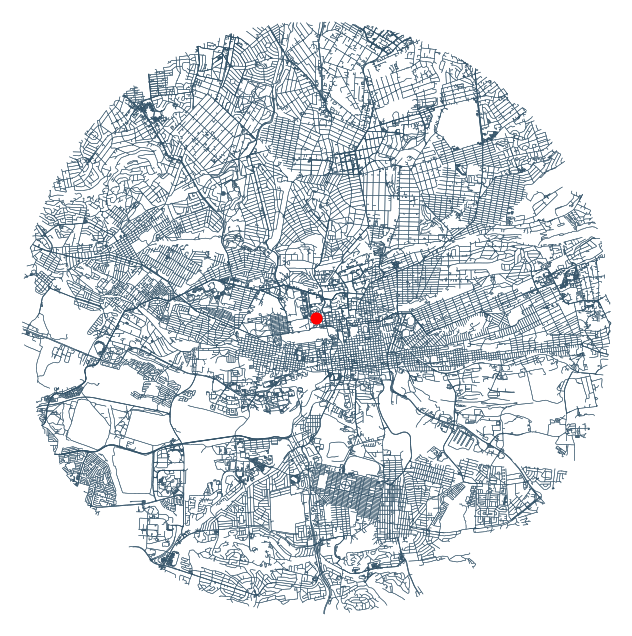

In [ ]:
import matplotlib.pyplot as plt

fig, ax = ox.plot_graph(
    graph,
    node_size=0,
    edge_color="#34546A",
    edge_linewidth=0.35,
    bgcolor="white",
    show=False,
    close=False,
)

# Mark Wits Main Campus
ax.scatter(28.0303, -26.1928, color="red", s=60, zorder=5)

# Add marks for key areas of interest (e.g. residences, libraries, etc.)

plt.show()

## 1. Audit what the map actually knows

OSM records `lit=*` and `sidewalk=*` where contributors have mapped them. **Missing means unknown**, not unlit or no sidewalk. Road class is only a rough traffic proxy; it is not measured traffic volume. Inspect coverage before trusting a score. Crossing quality and whether lamps currently work require local verification.

In [4]:
from collections import Counter

lighting = Counter()
sidewalks = Counter()
for _, _, _, data in graph.edges(keys=True, data=True):
    light, pavement, _ = street_conditions(data)
    lighting[light] += 1
    sidewalks[pavement] += 1
print("Lighting tags:", dict(lighting))
print("Sidewalk tags:", dict(sidewalks))
print("Treat unknown values separately in the app and in any evaluation.")

Lighting tags: {'unknown': 339804, 'lit': 890, 'unlit': 26}
Sidewalk tags: {'unknown': 339304, 'mapped': 1392, 'none': 24}
Treat unknown values separately in the app and in any evaluation.


## 2. Score and search routes

`route_core.py` starts with **1 point per 100 m walked**, plus **3 for confirmed unlit streets**, **3 for explicitly absent sidewalks**, **2 for major-road exposure**, and smaller penalties for unknown lighting/sidewalks. A crossing explicitly tagged as unmarked adds 4 points. The weights are provisional. The app lets users set a maximum *continuous* unlit stretch, maximum detour, and whether to exclude unknown lighting.

The starter search checks the first 100 score-ranked candidate paths. Therefore, an empty result means **none among those candidates** met the limits; it does not prove that no feasible route exists. The next engineering step is an exact state-augmented constrained-path solver.

In [5]:
# Replace these coordinates with the two places you want to demo.
START = (-26.1928, 28.0303)       # (latitude, longitude), Wits Main Campus
END = (-26.189375, 28.024797)     # example destination near West Campus

start_node = nearest_node(graph, START[0], START[1])
end_node = nearest_node(graph, END[0], END[1])
routes, search = find_routes(
    graph, start_node, end_node,
    max_unlit_m=100,
    max_detour_pct=20,
    avoid_unknown_lighting=False,
    candidates_to_check=100,
)
print("Search:", search)
for index, (_, profile) in enumerate(routes, 1):
    print(f"Route {index}:", profile)
if not routes:
    print("No qualifying route among the candidates checked; try more candidates or different limits.")

Search: {'shortest_m': 813.1, 'allowed_m': 975.7, 'checked_up_to': 100}
Route 1: {'distance_m': 813.1, 'score': 28.46, 'longest_unlit_m': 0.0, 'unknown_lighting_m': 813.1, 'missing_sidewalk_m': 0.0}
Route 2: {'distance_m': 829.3, 'score': 29.03, 'longest_unlit_m': 0.0, 'unknown_lighting_m': 829.3, 'missing_sidewalk_m': 0.0}
Route 3: {'distance_m': 831.3, 'score': 29.09, 'longest_unlit_m': 0.0, 'unknown_lighting_m': 831.3, 'missing_sidewalk_m': 0.0}


## 3. QAOA experiment on a small network

The 10 km graph is too large for a direct QAOA demonstration. Start with a small **toy subgraph**, where each edge is a binary choice. The QAOA objective minimises route score, and flow constraints force a connected origin-to-destination path. The code below runs only after installing `qiskit`, `qiskit-algorithms`, and `qiskit-optimization` in a compatible Python environment. Your current classical app does not require them.

This first quantum experiment encodes score and connectivity. A later experiment should encode the detour and continuous-unlit constraints too, then compare validity, score, and runtime against a classical constrained solver. QAOA does not have a demonstrated speed advantage for this app.

In [6]:
# Optional: uv pip install qiskit qiskit-algorithms qiskit-optimization
try:
    from qiskit.primitives import StatevectorSampler
    from qiskit_algorithms import QAOA
    from qiskit_algorithms.optimizers import COBYLA
    from qiskit_optimization import QuadraticProgram
    from qiskit_optimization.algorithms import MinimumEigenOptimizer
except ImportError:
    print("QAOA packages are not installed. The classical route app still works.")
else:
    # Replace this tiny graph with a carefully selected local subgraph later.
    toy_edges = {
        "sa": ("s", "a", 2.0), "at": ("a", "t", 2.0),
        "sb": ("s", "b", 1.0), "bc": ("b", "c", 1.0),
        "ct": ("c", "t", 4.0), "ac": ("a", "c", 1.5),
    }
    qp = QuadraticProgram()
    for edge_id in toy_edges:
        qp.binary_var(name=edge_id)
    qp.minimize(linear={edge_id: edge[2] for edge_id, edge in toy_edges.items()})
    for node in ("s", "a", "b", "c", "t"):
        flow = {
            edge_id: int(start == node) - int(end == node)
            for edge_id, (start, end, _) in toy_edges.items()
        }
        qp.linear_constraint(
            linear=flow, sense="==",
            rhs=1 if node == "s" else -1 if node == "t" else 0,
            name=f"flow_{node}",
        )
    qaoa = QAOA(sampler=StatevectorSampler(seed=7), optimizer=COBYLA(maxiter=80), reps=1)
    result = MinimumEigenOptimizer(qaoa).solve(qp)
    chosen = [name for name, bit in zip(toy_edges, result.x) if bit > 0.5]
    print("QAOA toy path edges:", chosen, "objective:", result.fval)
    print("Next: add the user constraints to the quantum model, then benchmark it.")

/Users/courtneybrown/Library/Mobile Documents/com~apple~CloudDocs/PhD/Hackathon/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/courtneybrown/Library/Mobile Documents/com~apple~CloudDocs/PhD/Hackathon/.venv/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/Users/courtneybrown/Library/Mobile Documents/com~apple~CloudDocs/PhD/Hackathon/.venv/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


QAOA toy path edges: ['sa', 'at'] objective: 4.0
Next: add the user constraints to the quantum model, then benchmark it.


## 4. Run the app

The accompanying `app.py` gives users coordinate inputs plus sliders for maximum unlit stretch and detour. It shows route scores and a map. Install Streamlit inside your existing venv, then run:

```bash
uv pip install streamlit pydeck
streamlit run app.py
```

The app uses `route_core.py` and the saved GraphML file. Start with a short journey near Wits while testing. Record which street attributes are missing, and survey a few routes before presenting any condition score as verified.